<a href="https://colab.research.google.com/github/ghn9zh/DS3001-programming/blob/main/assignment_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment: $k$ Means Clustering

### `! git clone https://www.github.com/ds4e/clustering`

### **Do Q1 and one other question.**

**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

In [ ]:
! git clone https://www.github.com/ds4e/clustering

Cloning into 'clustering'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 30 (delta 2), reused 1 (delta 1), pack-reused 25 (from 1)
Receiving objects: 100% (30/30), 4.72 MiB | 5.60 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

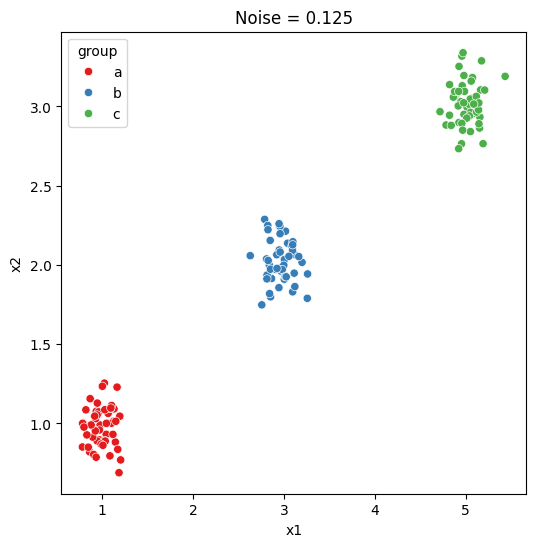

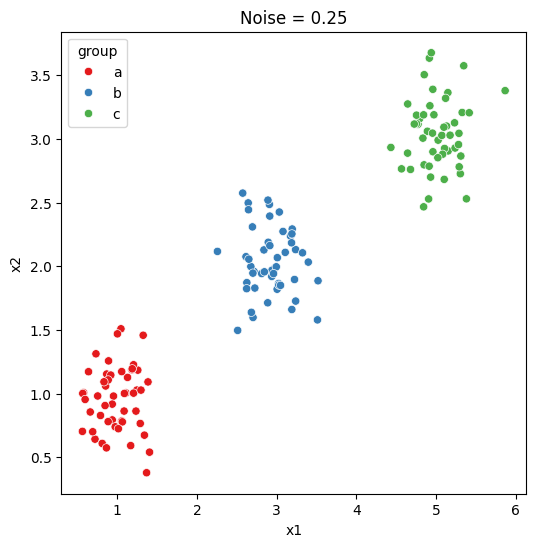

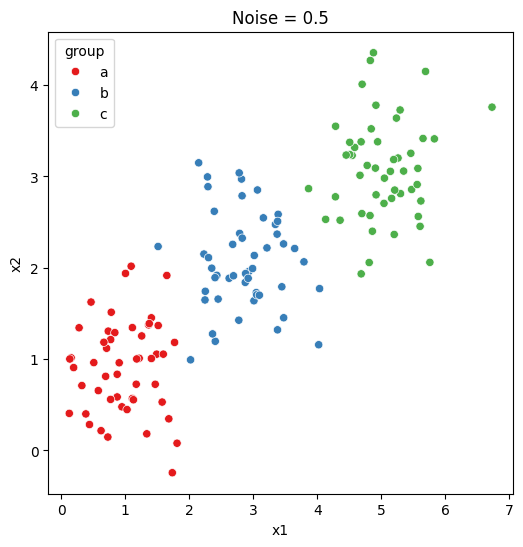

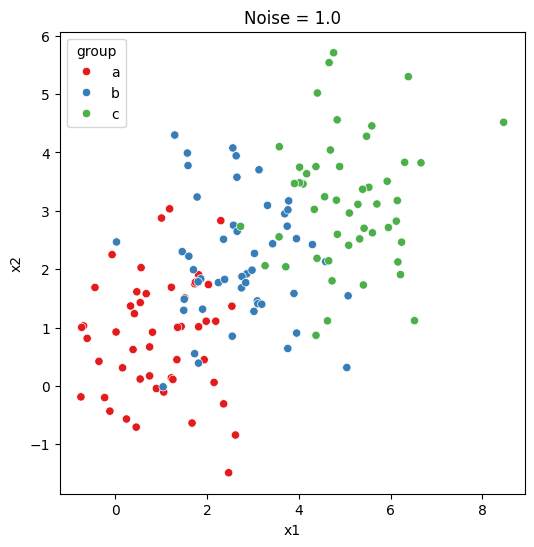

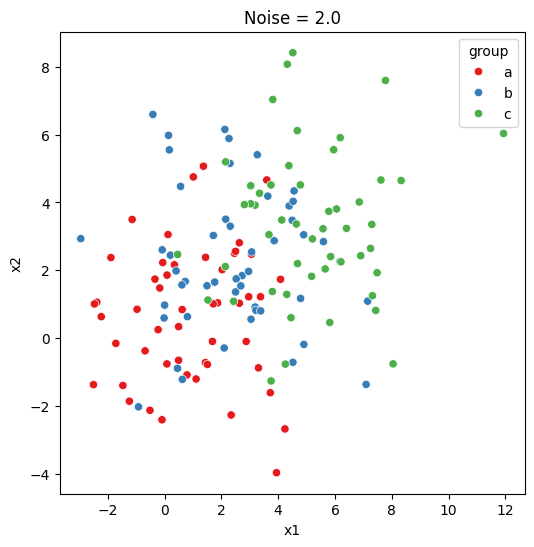

In [ ]:
#Question 2

import seaborn as sns
import matplotlib.pyplot as plt

def plot_scatter(df, title):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=df, x='x1', y='x2', hue='group', palette='Set1')
    plt.title(title)
    plt.show()

plot_scatter(df0_125, 'Noise = 0.125')
plot_scatter(df0_25, 'Noise = 0.25')
plot_scatter(df0_5, 'Noise = 0.5')
plot_scatter(df1_0, 'Noise = 1.0')
plot_scatter(df2_0, 'Noise = 2.0')

#As noise increase the clusters become less distinct. At low noise the groups are very tight and seperate.
#By noise=1.0 the clusters start overlapping a little bit. By noise=2 the clusters are pretty much gone.

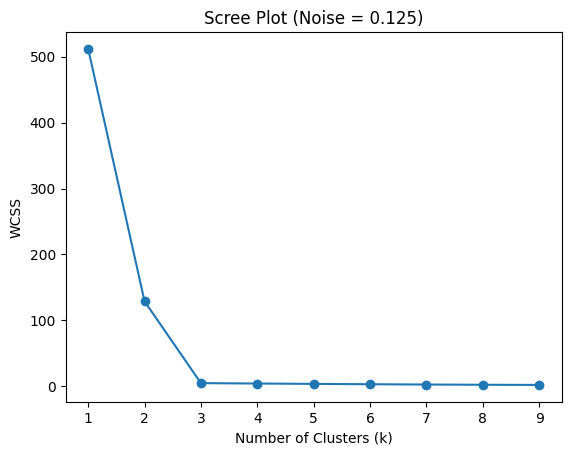

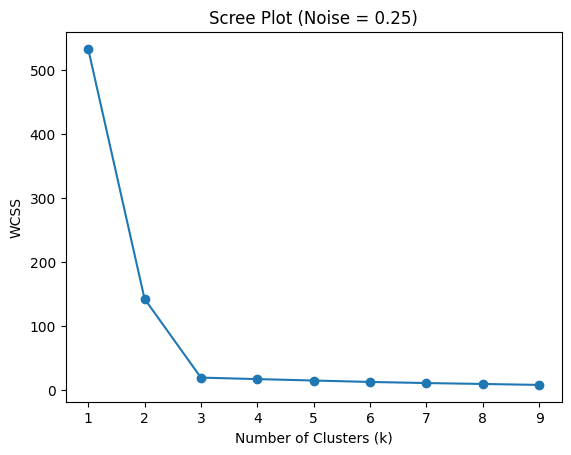

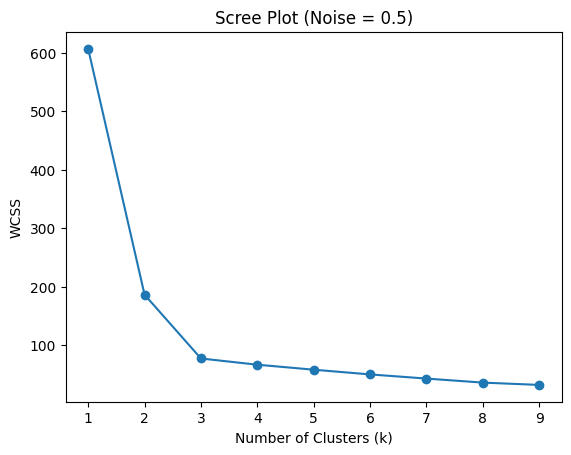

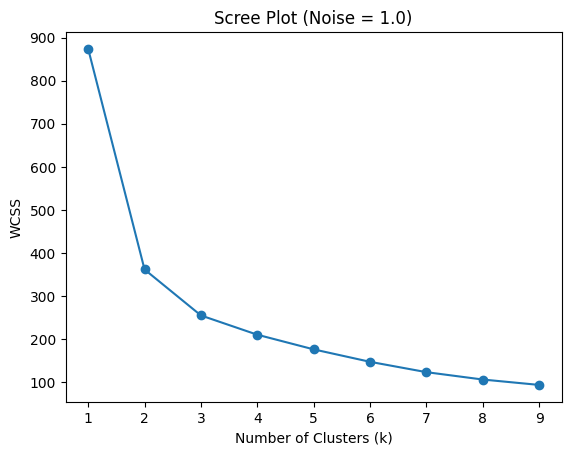

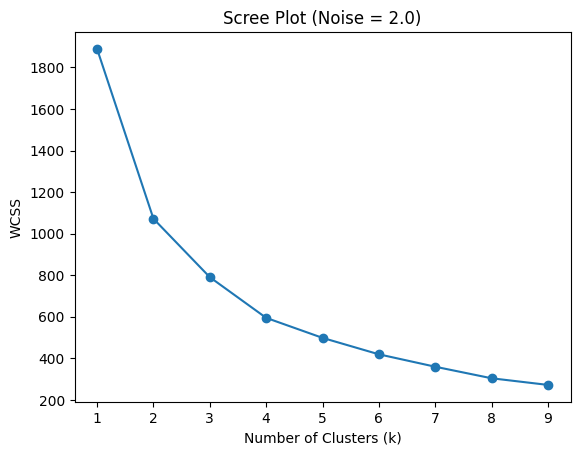

In [ ]:
#Question 3:

from sklearn.cluster import KMeans

def scree_plot(df, noise_level):
    X = df[['x1', 'x2']].values
    wcss = []
    k_range = range(1, 10)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=100, n_init=10)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)

    plt.plot(k_range, wcss, marker='o')
    plt.title(f'Scree Plot (Noise = {noise_level})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS')
    plt.show()

scree_plot(df0_125, 0.125)
scree_plot(df0_25, 0.25)
scree_plot(df0_5, 0.5)
scree_plot(df1_0, 1.0)
scree_plot(df2_0, 2.0)

#When noise is low (0.125) there is a clear elbow at k=3 which matches the amount of clusters.
#As noise increase (.5, 1.0, 2.0) the elbow becomes less distical and the curve is more gradual.
#This shows as clusters over lap more it becomes more difficult to determine the optimal k.


Question 4: The elbow method helps find the optimal number of clusters, k, by plottinf the within-cluster sum of squares (WCCS) for difference k values. The "elbow" is the point where adding more clusters does not significanlty reduce the WCSS. When noise is low, the data natually falls into distinct groups, so the elbow is sharp. When noise is high, the groups overlap, so the WCSS decreases more gradually, making it harder to find a clear elbow. In the real-world where cleaner data (less noise) allows clearer identification of natural clusters, while noisy data makes clustering ambigous. At noise =.0125 the data forms 3 tigh clusters and you see a sharp drop at k=3. At noise=2.0, the data becomes a big cloud, and the WCSS drops smoothly, meaning there is no obvious best k.

**Q2.** This question is a case study on clustering.

1. Load the `2022 election cycle fundraising.csv` file in the `./data` folder. This has campaign finance data for the 2022 election for House and Senate candidates. We're going to focus on the total amount they raised, `Raised`, the total amount they spent, `Spent`, their available `Cash on Hand`, and their `Debts`. The variables denominated in dollars are messy and require cleaning. How do you handle it?
2. Max-min normalize `Raised` and `Spent`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Raised` against `Spent` and hue the dots by their cluster membership. What do you see? Which politicians comprise the smallest two clusters? If necessary, look up some of these races to see how close they were.
3. Repeat part 2, but for `Cash on Hand` and `Debts`. Compare your results with part 2. Why might this be? If necessary, look up some of these races to see how close they were.
4. Use $k$ means clustering with all four numeric variables. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find useful patterns for you in analyzing the election?

**Q3.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the election?

**Q4.** This question is a case study for $k$ means clustering.

1. Load the `airbnb_hw.csv` data. Clean `Price` along with `Beds`, `Number of Reviews`, and `Review Scores Rating`.
2. Maxmin normalize the data and remove any `nan`'s (`KMeans` from `sklearn` doesn't accept `nan` input).
3. Use `sklearn`'s `KMeans` module to cluster the data by `Beds`, `Number of Reviews`, and `Review Scores Rating` for `k=6`.
4. Use `seaborn`'s `.pairplot()` to make a grid of scatterplots that show how the clustering is carried out in multiple dimensions.
5. Use `.groupby` and `.describe` to compute the average price for each cluster. Which clusters have the highest rental prices?
6. Use a scree plot to pick the number of clusters and repeat steps 4 and 5.

In [7]:
#Part 1:

import pandas as pd

# Load the data
df = pd.read_csv('/content/clustering/assignment/data/airbnb_hw.csv')

# Preview the first few rows
print(df.head())

# Keep only the needed columns and clean 'Price'
df = df[['Price', 'Beds', 'Number Of Reviews', 'Review Scores Rating']]

# Remove rows where any of the columns have missing values
df = df.dropna()

# Clean and convert Price to numeric (if there are symbols like $, remove them)
df['Price'] = df['Price'].replace('[\$,]', '', regex=True).astype(float)

# Check for missing values again
print(df.isnull().sum())
print(df.describe())


    Host Id Host Since                                Name Neighbourhood   \
0   5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                Sunny Room in Harlem      Manhattan   
3       500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008            Trendy Times Square Loft      Manhattan   

  Property Type  Review Scores Rating (bin)        Room Type  Zipcode  Beds  \
0     Apartment                         NaN  Entire home/apt  11249.0   1.0   
1     Apartment                         NaN     Private room  11206.0   1.0   
2     Apartment                         NaN     Private room  10032.0   1.0   
3     Apartment                         NaN  Entire home/apt  10024.0   3.0   
4     Apartment                        95.0     Private room  10036.0   3.0   

   Number of Records  Number Of Reviews Price  Review Scores R

In [8]:
#Part 2:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize relevant columns
columns_to_normalize = ['Beds', 'Number Of Reviews', 'Review Scores Rating']
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

# Check the data
print(df.head())


   Price    Beds  Number Of Reviews  Review Scores Rating
4  549.0  0.1875           0.148438                 0.950
5  149.0  0.0625           0.011719                 1.000
6  250.0  0.0625           0.031250                 1.000
7   90.0  0.0625           0.308594                 0.925
8  270.0  0.1250           0.367188                 0.875


In [9]:
#Part 3:

from sklearn.cluster import KMeans

# Fit KMeans
kmeans = KMeans(n_clusters=6, random_state=100, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[columns_to_normalize])

# Check clusters
print(df['Cluster'].value_counts())
print(df.head())


Cluster
2    7770
5    7486
0    2860
4    1796
1    1750
3     449
Name: count, dtype: int64
   Price    Beds  Number Of Reviews  Review Scores Rating  Cluster
4  549.0  0.1875           0.148438                 0.950        1
5  149.0  0.0625           0.011719                 1.000        2
6  250.0  0.0625           0.031250                 1.000        2
7   90.0  0.0625           0.308594                 0.925        4
8  270.0  0.1250           0.367188                 0.875        4


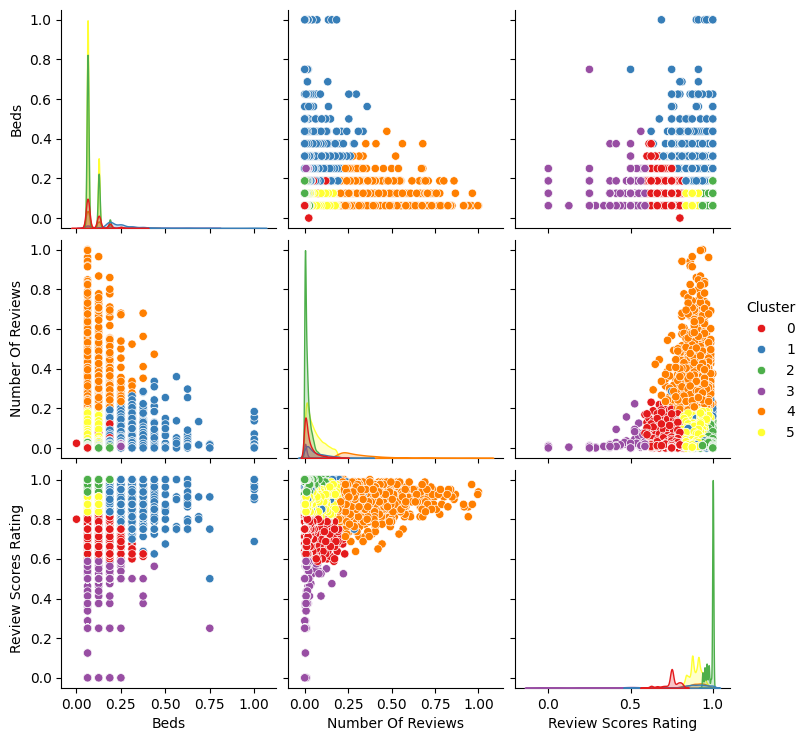

In [10]:
#Part 4:

import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot
sns.pairplot(df, vars=['Beds', 'Number Of Reviews', 'Review Scores Rating'], hue='Cluster', palette='Set1')
plt.show()


In [11]:
#Part 5:

# Group by cluster and describe price for each cluster
price_summary = df.groupby('Cluster')['Price'].describe()
print(price_summary)

# Find clusters with the highest average prices
print(price_summary.sort_values('mean', ascending=False))

#Cluster 1 has the highest mean rental price by far. Followed by cluster 2 and then the rest are pretty even.

          count        mean         std   min    25%    50%    75%      max
Cluster                                                                    
0        2860.0  132.616084  125.243897  20.0   70.0  109.0  165.0   5000.0
1        1750.0  290.226857  255.826627  27.0  150.0  225.0  350.0   4500.0
2        7770.0  154.495753  119.867778  10.0   85.0  130.0  195.0   3500.0
3         449.0  130.748330  245.586863  25.0   60.0   90.0  150.0   5000.0
4        1796.0  135.643096   78.938720  27.0   85.0  120.0  170.0    875.0
5        7486.0  137.967139  138.954817  22.0   83.0  120.0  175.0  10000.0
          count        mean         std   min    25%    50%    75%      max
Cluster                                                                    
1        1750.0  290.226857  255.826627  27.0  150.0  225.0  350.0   4500.0
2        7770.0  154.495753  119.867778  10.0   85.0  130.0  195.0   3500.0
5        7486.0  137.967139  138.954817  22.0   83.0  120.0  175.0  10000.0
4        179

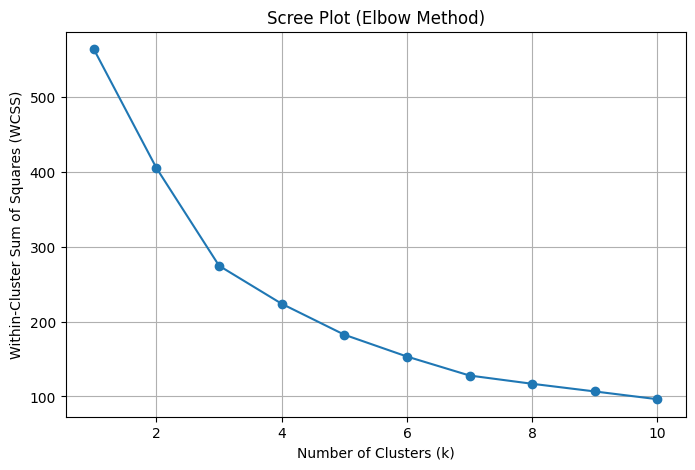

In [12]:
#Part 6:

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=100, n_init=10)
    kmeans.fit(df[columns_to_normalize])
    wcss.append(kmeans.inertia_)

# Plot Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.title('Scree Plot (Elbow Method)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()


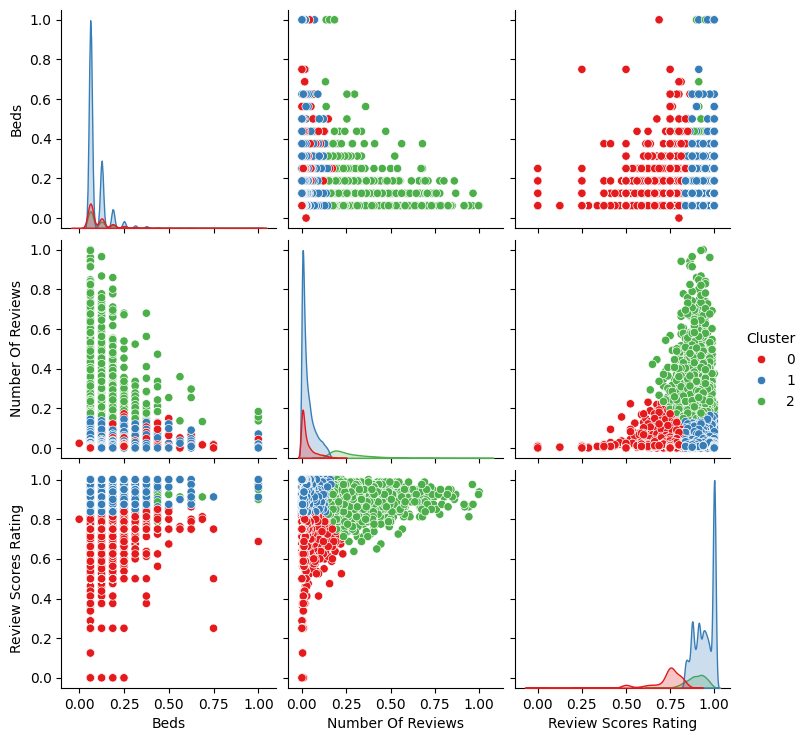

           count        mean         std   min   25%    50%    75%      max
Cluster                                                                    
1        15854.0  160.104327  155.342498  10.0  88.0  130.0  195.0  10000.0
2         2508.0  143.040271   94.982561  22.0  85.0  120.0  175.0   1500.0
0         3749.0  140.228061  149.219013  20.0  70.0  110.0  175.0   5000.0


In [13]:
#Part 6: re-run with New Optimal K =3

kmeans = KMeans(n_clusters=3, random_state=100, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[columns_to_normalize])

# Pairplot again
sns.pairplot(df, vars=['Beds', 'Number Of Reviews', 'Review Scores Rating'], hue='Cluster', palette='Set1')
plt.show()

# Price summary again
price_summary = df.groupby('Cluster')['Price'].describe()
print(price_summary.sort_values('mean', ascending=False))

#Based on k=3, clsuter 1 has the highest mean price.


**Q5.** We looked at computer vision with $k$NN in a previous question. Can $k$ means clustering correctly group digits, even if we don't know which symbols are which?

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use $k$ means clustering on the reshaped `X_test` data with `k=10`.  
5. Cross tabulate the cluster assignments with the true labels for the test set values. How good is the correspondence? What proportion of digits are clustered correctly? Which digits are the hardest to distinguish from one another? Can $k$MC recover the latent digits 0 to 9, without even knowing what those digits were?
6. If you use a scree plot to determine the number of clusters $k$, does it pick 10 (the true number of digits), or not? If it fails to pick $k=10$, which digits does it tend to combine into the same classification?